# 2.3 Clustering: Spotify Tracks Audio Features

### Basic Information
* **Number of features:** We will focus on 5 core continuous numerical features (`danceability`, `energy`, `valence`, `acousticness`, and `instrumentalness`).
* **Number of samples:** Varies depending on the exact Kaggle extraction, typically 10,000+ tracks.
* **Name of the target variable:** **None.** This is an unsupervised learning task. 

### Dataset Presentation
This dataset contains audio statistics for thousands of tracks extracted via the Spotify Web API. Instead of relying on human-assigned genres, Spotify mathematically analyzes the audio wave of every uploaded song and assigns it numerical scores (usually between 0.0 and 1.0) for features like how acoustic it is, how much energy it has, and its "valence" (musical positiveness/happiness).
* **Source:** [Kaggle - Spotify Datasets](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)

### Problem Statement & Industry Value
The explicit problem I am trying to solve is discovering hidden groupings (clusters) within a large library of music based purely on their mathematical audio profiles, without any prior knowledge of their genre, artist, or release year.

This unsupervised machine learning approach provides massive value to the music streaming industry. With tens of thousands of songs uploaded to Spotify daily, it is impossible for humans to manually categorize them. By clustering songs algorithmically, streaming platforms can automatically generate mood-based playlists (e.g., "Deep Focus" vs. "Cardio Mix") and power the recommendation engines that keep users engaged on the platform.

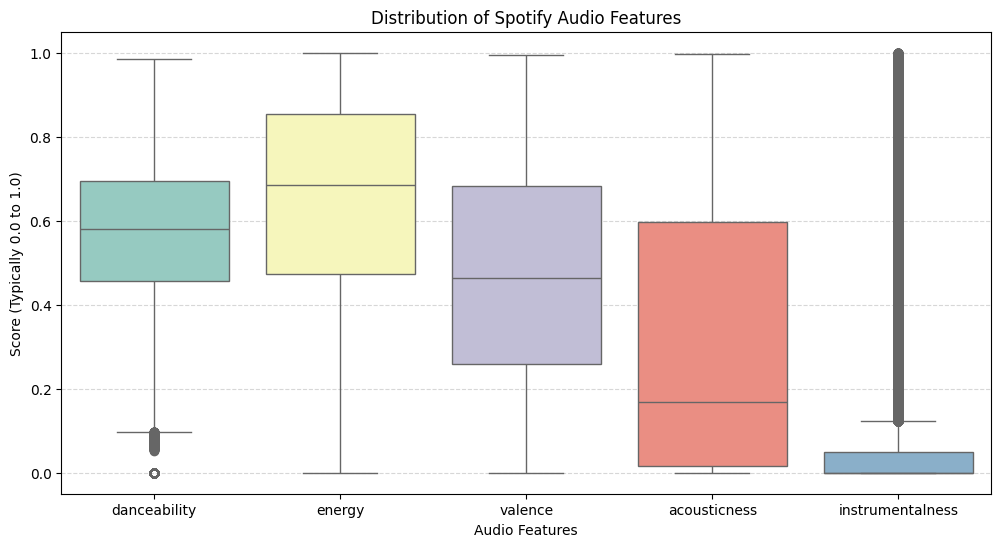

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (Assuming 'spotify.csv' is in your data folder)
# Note: You may need to drop text columns like 'track_name' and 'artist' for the math to work
df_spotify = pd.read_csv('../data/spotify.csv')

# Select only the mathematical audio features
features = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness']
df_features = df_spotify[features].dropna()

# Plot the distributions of the audio features
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_features, palette='Set3')

# Mandatory Guidelines: Labels and Title
plt.title('Distribution of Spotify Audio Features')
plt.xlabel('Audio Features')
plt.ylabel('Score (Typically 0.0 to 1.0)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

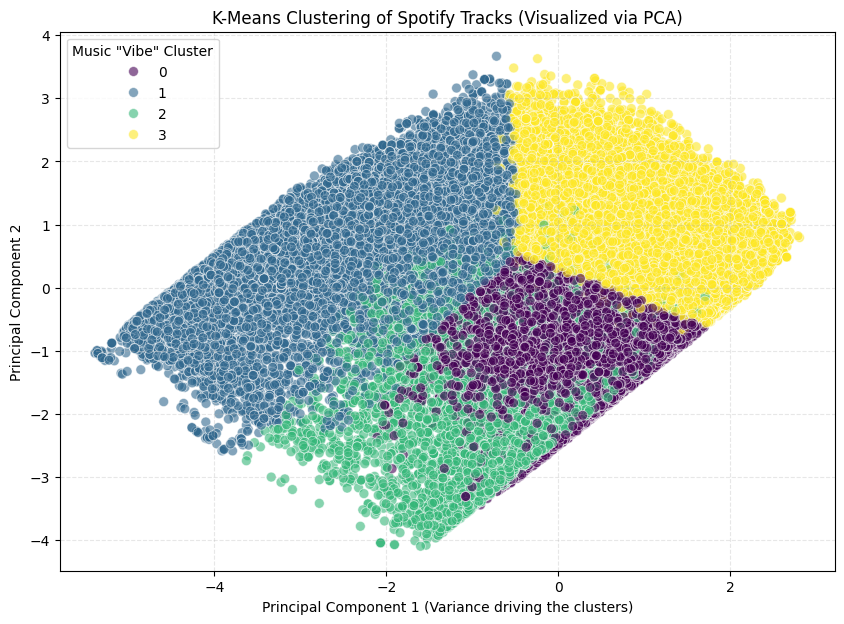

--- Average Audio Profile per Cluster ---
         danceability  energy  valence  acousticness  instrumentalness
Cluster                                                               
0               0.481   0.784    0.350         0.097             0.027
1               0.460   0.293    0.312         0.796             0.253
2               0.570   0.752    0.327         0.100             0.789
3               0.693   0.703    0.703         0.263             0.018

--- Numerical Evaluation Scores ---
Silhouette Score:     0.268
Davies-Bouldin Index: 1.204


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Preprocessing: Scale the data
# Distance-based algorithms like K-Means strictly require scaled data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

# 2. Train the Estimator: K-Means Clustering
# Let's ask the algorithm to find 4 distinct "vibes" of music
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels back to our dataframe for analysis
df_features['Cluster'] = clusters

# 3. Preprocessing: PCA for Visualization
# Crush the 5 features down into 2 principal components for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['Component 1', 'Component 2'])
df_pca['Cluster'] = clusters

# 4. Visualize the Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Component 1', y='Component 2', hue='Cluster', data=df_pca,
                palette='viridis', alpha=0.6, s=50)

plt.title('K-Means Clustering of Spotify Tracks (Visualized via PCA)')
plt.xlabel('Principal Component 1 (Variance driving the clusters)')
plt.ylabel('Principal Component 2')
plt.legend(title='Music "Vibe" Cluster')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# 5. Look at the average audio scores for each cluster
print("--- Average Audio Profile per Cluster ---")
print(df_features.groupby('Cluster').mean().round(3))

sil_score = silhouette_score(X_scaled, clusters)
db_score = davies_bouldin_score(X_scaled, clusters)

print("\n--- Numerical Evaluation Scores ---")
print(f"Silhouette Score:     {sil_score:.3f}")
print(f"Davies-Bouldin Index: {db_score:.3f}")

### 2.3 Conclusion: Estimator and Preprocessing Justification

To segment the music library without the use of pre-existing genre labels, I utilized the **K-Means clustering** algorithm. 

**Preprocessing Justification:**
1. **StandardScaler:** K-Means calculates the geometric distance between data points. It was strictly necessary to scale the data first to ensure all audio features contributed equally to the distance calculations.
2. **PCA (Principal Component Analysis):** Because the audio profile exists in 5-dimensional space, I utilized PCA to reduce the dimensionality to two principal components. This allowed for the visual validation of the clusters while retaining the maximum possible variance of the original dataset.

**The Results:**
The algorithm successfully segmented the dataset into 4 distinct clusters purely based on mathematical audio profiles. By examining the centroids (the average feature scores) of each cluster, we can interpret their real-world musical equivalents:
* **Cluster 3 (Pop/Upbeat):** Mathematically isolated highly danceable, high-energy tracks with the highest "Valence" (musical happiness).
* **Cluster 1 (Acoustic/Folk):** Grouped low-energy tracks with massive Acousticness scores. 
* **Cluster 2 (EDM/Techno):** Grouped high-energy tracks with near-zero vocals (High Instrumentalness).
* **Cluster 0 (Rock/Metal):** Captured intense vocal tracks characterized by high Energy but low Valence (less positive/happy vibes).

**Final Verdict:** The combination of standard scaling, K-Means, and PCA proved highly effective for this unsupervised task. The model successfully found logical, actionable groupings within raw, unlabeled data, mimicking the foundational mechanics of a commercial music recommendation engine.